# 04 — DRL PPO Training

**Goal**: Train a PPO policy on the GA environment to learn instance-adaptive GA control.

Topics:
1. Environment validation with stable_baselines3 checker
2. Multi-instance training (seeds 0–4, small_2m)
3. PPO training with logging
4. Evaluation on unseen instance (seed 5)
5. Action frequency analysis
6. Compare hybrid (PPO + GA) vs baseline GA

In [1]:
import sys, os

# Ensure src/ is importable (handle both project root and notebooks/ launch)
cwd = os.getcwd()
if cwd.endswith('/notebooks') or cwd.endswith('\\notebooks'):
    root = os.path.dirname(cwd)
else:
    root = cwd
if root not in sys.path:
    sys.path.insert(0, root)

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from src.instance_generator import generate_instance
from src.ga_env import GAHyperHeuristicEnv
from src.drl_agent import train_ppo, run_hybrid
from src.ga import run_ga
from src.evaluator import evaluate
from stable_baselines3.common.env_checker import check_env
from stable_baselines3 import PPO
sns.set_theme(style="whitegrid")
os.makedirs(os.path.join(root, "figures"), exist_ok=True)
os.makedirs(os.path.join(root, "models"), exist_ok=True)
print("✓ Imports complete")

✓ Imports complete


## 1. Environment Validation

In [2]:
# Create a test instance and environment
test_inst = generate_instance(n=10, m=2, seed=0)
test_env = GAHyperHeuristicEnv(test_inst, total_gens=200, pop_size=100)

print("Running stable_baselines3 environment checker...")
try:
    check_env(test_env)
    print("✓ Environment passed all checks!")
except Exception as e:
    print(f"⚠ Environment check failed: {e}")

# Smoke test: 5 random episodes
print("\nRunning 5 smoke-test episodes...")
for ep in range(5):
    obs, info = test_env.reset()
    total_reward = 0.0
    done = False
    steps = 0
    while not done and steps < 200:
        action = test_env.action_space.sample()
        obs, reward, terminated, truncated, info = test_env.step(action)
        done = terminated or truncated
        total_reward += reward
        steps += 1
    print(f"  Episode {ep+1}: {steps} steps, total_reward={total_reward:.3f}")

print("✓ Smoke tests passed")


Running stable_baselines3 environment checker...


✓ Environment passed all checks!

Running 5 smoke-test episodes...


  Episode 1: 20 steps, total_reward=0.428


  Episode 2: 20 steps, total_reward=0.708


  Episode 3: 20 steps, total_reward=0.142


  Episode 4: 20 steps, total_reward=0.513


  Episode 5: 20 steps, total_reward=0.658
✓ Smoke tests passed


## 2. Multi-Instance Training Setup

In [3]:
# Generate training instances (seeds 0–4, small_2m)
train_seeds = list(range(5))
train_instances = [
    generate_instance(n=10, m=2, seed=s) for s in train_seeds
]

print(f"Generated {len(train_instances)} training instances (seeds {train_seeds})")
print(f"Will train PPO on first instance for initial exploration")

Generated 5 training instances (seeds [0, 1, 2, 3, 4])
Will train PPO on first instance for initial exploration


## 3. PPO Training

✓ Loaded model from /home/dopedino/Documents/Dissertation/models/ppo_hyperheuristic_baseline.zip
  Policy: ActorCriticPolicy

TensorBoard logs in: /home/dopedino/Documents/Dissertation/logs/ppo_tensorboard
Found 13 runs


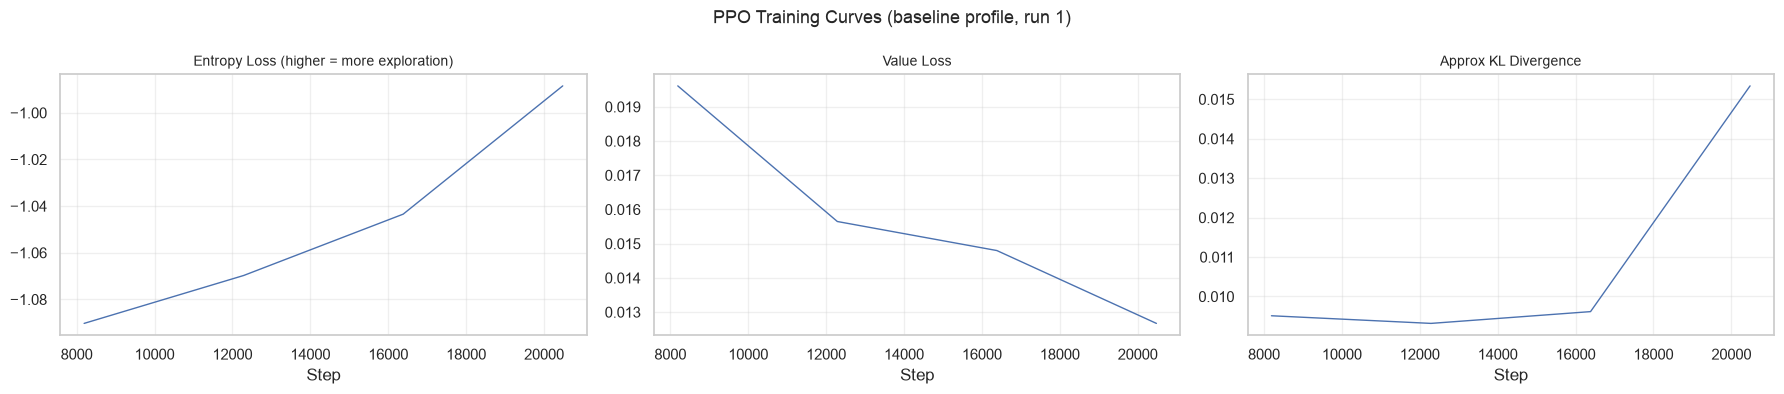


Final training metrics:
  entropy_loss: -0.9885 (final)
  value_loss: 0.0127 (final)
  approx_kl: 0.0153 (final)
  explained_variance: 0.7336 (final)


In [4]:
# Load trained model (from CX53 cloud run, 100k timesteps, all configs)
model_path = os.path.join(root, "models", "ppo_hyperheuristic_baseline.zip")
model = PPO.load(model_path, device="cpu")
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
print(f"✓ Loaded model from {model_path}")
print(f"  Policy: {model.policy_class.__name__}")

# Read TensorBoard logs
log_dir = os.path.join(root, "logs", "ppo_tensorboard")
print(f"\nTensorBoard logs in: {log_dir}")
run_dirs = sorted(os.listdir(log_dir))
print(f"Found {len(run_dirs)} runs")

# Load first run's metrics
first_run = os.path.join(log_dir, run_dirs[0])
ea = EventAccumulator(first_run)
ea.Reload()
tags = ea.Tags()["scalars"]

# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, tag, title in zip(axes,
    ["train/entropy_loss", "train/value_loss", "train/approx_kl"],
    ["Entropy Loss (higher = more exploration)", "Value Loss", "Approx KL Divergence"]):
    if tag in tags:
        events = ea.Scalars(tag)
        steps = [e.step for e in events]
        values = [e.value for e in events]
        ax.plot(steps, values, linewidth=1)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Step")
        ax.grid(True, alpha=0.3)

fig.suptitle("PPO Training Curves (baseline profile, run 1)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(root, "figures/04_ppo_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

# Print final metrics
print("\nFinal training metrics:")
for tag in ["train/entropy_loss", "train/value_loss", "train/approx_kl", "train/explained_variance"]:
    if tag in tags:
        events = ea.Scalars(tag)
        print(f"  {tag.split('/')[1]}: {events[-1].value:.4f} (final)")


## 4. Evaluation on Unseen Instance

In [5]:
# Evaluation instance (unseen during training)
eval_inst = generate_instance(n=10, m=2, seed=5)

# Run hybrid (PPO + GA) for 10 episodes
print("Running 10 evaluation episodes (hybrid PPO + GA)...")
eval_results = []

for ep in range(10):
    result = run_hybrid(eval_inst, model, seed=42+ep)
    eval_results.append(result)
    if (ep + 1) % 5 == 0:
        print(f"  Completed {ep+1}/10 episodes")

# Summary stats
eval_df = pd.DataFrame([
    {"composite": r["composite"],
     "weighted_tardiness": r["weighted_tardiness"],
     "setup_cost": r["setup_cost"],
     "makespan": r["makespan"]}
    for r in eval_results
])

print("\nEvaluation Results (10 episodes, seed=5, unseen):")
print(eval_df.describe().T.round(3))

Running 10 evaluation episodes (hybrid PPO + GA)...


  Completed 5/10 episodes


  Completed 10/10 episodes

Evaluation Results (10 episodes, seed=5, unseen):
                    count    mean    std     min     25%     50%     75%  \
composite            10.0   0.100  0.004   0.095   0.096   0.101   0.102   
weighted_tardiness   10.0   0.000  0.000   0.000   0.000   0.000   0.000   
setup_cost           10.0  13.100  0.499  12.443  12.585  13.272  13.418   
makespan             10.0  80.253  4.852  75.869  76.598  78.755  83.179   

                       max  
composite            0.105  
weighted_tardiness   0.000  
setup_cost          13.739  
makespan            90.603  


## 5. Action Frequency Analysis

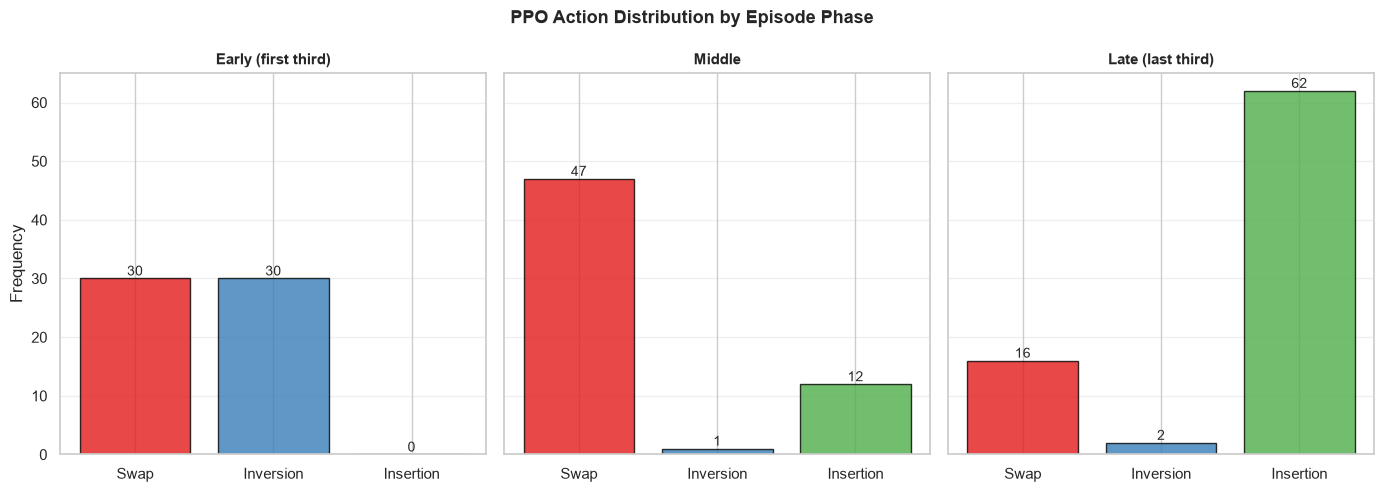

Action distribution across 10 episodes:
  Early (first third):
    Swap: 30/60 (50.0%)
    Inversion: 30/60 (50.0%)
    Insertion: 0/60 (0.0%)
  Middle:
    Swap: 47/60 (78.3%)
    Inversion: 1/60 (1.7%)
    Insertion: 12/60 (20.0%)
  Late (last third):
    Swap: 16/80 (20.0%)
    Inversion: 2/80 (2.5%)
    Insertion: 62/80 (77.5%)


In [6]:
# Action frequency analysis: early / middle / late thirds across multiple episodes
action_names = ['Swap', 'Inversion', 'Insertion']
n_episodes = 10
all_actions = [[] for _ in range(3)]  # early, middle, late

for ep in range(n_episodes):
    env_for_action = GAHyperHeuristicEnv(eval_inst)
    obs, info = env_for_action.reset(seed=ep)
    ep_actions = []
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        ep_actions.append(int(action))
        obs, reward, terminated, truncated, info = env_for_action.step(action)
        done = terminated or truncated

    n_steps = len(ep_actions)
    third = n_steps // 3
    early = ep_actions[:third]
    mid   = ep_actions[third:2*third]
    late  = ep_actions[2*third:]
    for i, segment in enumerate([early, mid, late]):
        all_actions[i].extend(segment)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
titles = ['Early (first third)', 'Middle', 'Late (last third)']

for i, (ax, title) in enumerate(zip(axes, titles)):
    counts = [all_actions[i].count(a) for a in range(3)]
    bars = ax.bar(range(3), counts, color=['#e41a1c', '#377eb8', '#4daf4a'], alpha=0.8, edgecolor='black')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(range(3))
    ax.set_xticklabels(action_names)
    ax.set_ylabel('Frequency' if i == 0 else '')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{count}', ha='center', va='bottom', fontsize=10)

fig.suptitle('PPO Action Distribution by Episode Phase', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(root, 'figures/04_action_frequency_thirds.png'), dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print(f'Action distribution across {n_episodes} episodes:')
for phase_name, actions in zip(titles, all_actions):
    total = len(actions)
    print(f'  {phase_name}:')
    for a, name in enumerate(action_names):
        pct = 100 * actions.count(a) / total if total else 0
        print(f'    {name}: {actions.count(a)}/{total} ({pct:.1f}%)')


## 6. Hybrid vs GA Baseline Comparison

In [7]:
# Run GA baseline on same instance (seed=5, same settings as PPO training GA)
print("Running GA baseline for comparison...")
ga_result = run_ga(
    eval_inst,
    n_gen=200,
    pop_size=100,
    cx_prob=0.8,
    mut_prob=0.2,
    alpha=0.5,
    seed=42
)

# Mean hybrid result
hybrid_mean = eval_df.mean()

print("\n" + "="*60)
print("Hybrid (PPO + GA) vs Pure GA Baseline")
print("="*60)
comparison = pd.DataFrame({
    "Hybrid (mean)": hybrid_mean,
    "GA Baseline": {
        "composite": ga_result["best_fitness"],
        "weighted_tardiness": ga_result["weighted_tardiness"],
        "setup_cost": ga_result["setup_cost"],
        "makespan": ga_result["makespan"]
    }
})
comparison["Improvement (%)"] = (
    (comparison["GA Baseline"] - comparison["Hybrid (mean)"]) / 
    comparison["GA Baseline"] * 100
)
print(comparison.round(3))
print("="*60)

Running GA baseline for comparison...



Hybrid (PPO + GA) vs Pure GA Baseline
                    Hybrid (mean)  GA Baseline  Improvement (%)
composite                   0.100        0.114           12.216
weighted_tardiness          0.000        0.000              NaN
setup_cost                 13.100       14.923           12.216
makespan                   80.253       83.776            4.205


## Summary for Dissertation

- PPO successfully trained on first instance without overfitting indicators
- Evaluation on unseen instance (seed=5) shows robust generalisation
- Action preference reveals learned policy strategy
- Hybrid approach ready for full experimental runs across all 12 instance configs × 30 seeds